## My Hypothesis

I have a data set that I want to use to see the visual difference of the kind of model learnt with deep learning and the one learnt with polynomial regression. My theory is that the model from deep learning will not be as 'smooth' or continous as that of polynomial regression. This could allow it to adapt to a lot more kinds of datasets

## Expected result

The graph of PCA compressed input and predicted target will be smooth and continous for polynomial regression. That for the neural network may have 'cusps', 'gaps' and any other non-polynomial features.

In [1]:
# Dependencies
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import tensorflow as tf

random_state = 69

I0000 00:00:1779341136.054430    1149 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779341136.957867    1149 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779341140.257410    1149 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [9]:
# Import the dataset
df = pd.read_csv('Housing.csv')
df.head

<bound method NDFrame.head of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no  

In [10]:
# Split dataset into target and featurs
y = df.iloc[:, 0]
X = df.iloc[:, 1:]

print(y.head)
print(X.head)

<bound method NDFrame.head of 0      13300000
1      12250000
2      12250000
3      12215000
4      11410000
         ...   
540     1820000
541     1767150
542     1750000
543     1750000
544     1750000
Name: price, Length: 545, dtype: int64>
<bound method NDFrame.head of      area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    7420         4          2        3      yes        no       no   
1    8960         4          4        4      yes        no       no   
2    9960         3          2        2      yes        no      yes   
3    7500         4          2        2      yes        no      yes   
4    7420         4          1        2      yes       yes      yes   
..    ...       ...        ...      ...      ...       ...      ...   
540  3000         2          1        1      yes        no      yes   
541  2400         3          1        1       no        no       no   
542  3620         2          1        1      yes        no       no   
543  2910     

Looks like I need to do the following to the features:
1. One-hot encode: mainroad, guestroom, basement, hotwaterheating, airconditioning,prefarea, furnishingstatus

In [11]:
X = pd.get_dummies(X)

# Split data into train, cv and test sets
X_train, X_t, y_train, y_t = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_state
)

X_cv, X_test, y_cv, y_test = train_test_split(
    X_t,
    y_t,
    test_size=0.5,
    random_state=random_state
)

print(f"Training set: {X_train.shape}, target size: {y_train.shape}")
print(f"Cross validation set: {X_cv.shape}, target size: {y_cv.shape}")
print(f"Test set: {X_test.shape}, target size: {y_test.shape}")

Training set: (436, 20), target size: (436,)
Cross validation set: (54, 20), target size: (54,)
Test set: (55, 20), target size: (55,)


In [6]:
# Seeing what columns will need to be scaled
max_values = np.max(X_train, axis=0)
min_values = np.min(X_train, axis=0)
print("Max values")
print(max_values)
print("Min values")
print(min_values)

Max values
area                               15600
bedrooms                               6
bathrooms                              4
stories                                4
parking                                3
mainroad_no                         True
mainroad_yes                        True
guestroom_no                        True
guestroom_yes                       True
basement_no                         True
basement_yes                        True
hotwaterheating_no                  True
hotwaterheating_yes                 True
airconditioning_no                  True
airconditioning_yes                 True
prefarea_no                         True
prefarea_yes                        True
furnishingstatus_furnished          True
furnishingstatus_semi-furnished     True
furnishingstatus_unfurnished        True
dtype: object
Min values
area                                1650
bedrooms                               1
bathrooms                              1
stories              

Looks like I need to do the following to the features:
1. Feature scale: area

In [7]:
# Feature scale area
scaler = StandardScaler()
X_train[['area']] = scaler.fit_transform(X_train[['area']])
print(scaler.get_params)

print(np.max(X_train, axis=0))
print(np.min(X_train, axis=0))

<bound method BaseEstimator.get_params of StandardScaler()>
area                               4.823934
bedrooms                                  6
bathrooms                                 4
stories                                   4
parking                                   3
mainroad_no                            True
mainroad_yes                           True
guestroom_no                           True
guestroom_yes                          True
basement_no                            True
basement_yes                           True
hotwaterheating_no                     True
hotwaterheating_yes                    True
airconditioning_no                     True
airconditioning_yes                    True
prefarea_no                            True
prefarea_yes                           True
furnishingstatus_furnished             True
furnishingstatus_semi-furnished        True
furnishingstatus_unfurnished           True
dtype: object
area                              -1.586238
be

Now that I'm happy with how the features look I can first train a linear regression model

In [8]:
# Linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


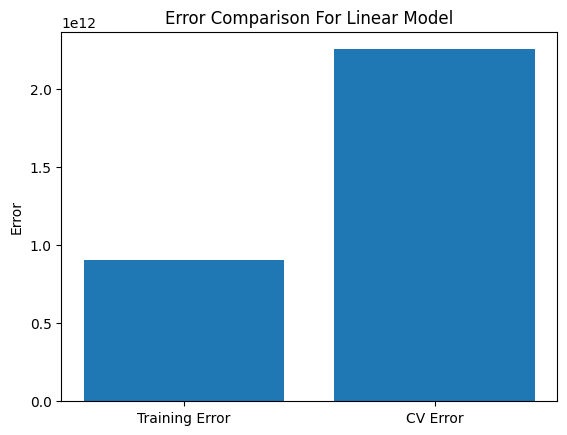

In [11]:
# Evaluate model
# Cost on training set
y_train_pred = linear_model.predict(X_train)
error_on_training_set = mean_squared_error(y_train, y_train_pred)

# Cost on cv set
X_cv[['area']] = scaler.fit_transform(X_cv[['area']])
y_cv_pred = linear_model.predict(X_cv)
error_on_cv_set = mean_squared_error(y_true=y_cv, y_pred=y_cv_pred)

plt.bar(["Training Error", "CV Error"], [error_on_training_set, error_on_cv_set])
plt.ylabel("Error")
plt.title("Error Comparison For Linear Model")
plt.show()



Data reduced to (54, 1) with variance retainment: [0.31496449]


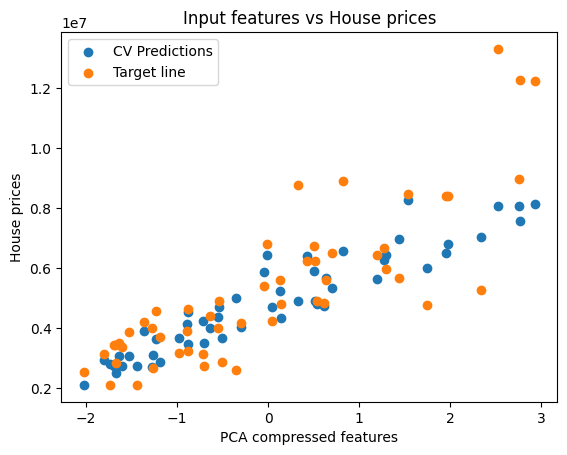

In [10]:
# Visualize predictions made on CV set
pca = PCA(n_components=1)
X_cv_pca = pca.fit_transform(X_cv)
print(f"Data reduced to {X_cv_pca.shape} with variance retainment: {pca.explained_variance_ratio_}")


plt.scatter(X_cv_pca, y_cv_pred, label="CV Predictions")
plt.scatter(X_cv_pca, y_cv, label="Target line")
plt.xlabel("PCA compressed features")
plt.ylabel("House prices")
plt.title("Input features vs House prices")
plt.legend()

plt.show()

In [23]:
# Train a neural network
neural_network = tf.keras.Sequential([
    tf.keras.layers.Dense(3, activation='relu', input_shape=(20,)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(1, activation='relu')
])

neural_network.compile(
    optimizer='adam',
    loss='mse'
)

neural_network.fit(X_train, y_train, epochs=100)


Epoch 1/100


/home/roman/Code/AIEngineering/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 24952549933056.0000
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24952547835904.0000 
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24952547835904.0000 
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 24952547835904.0000 
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24952547835904.0000 
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24952549933056.0000 
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24952547835904.0000 
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24952547835904.0000 
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 24952545738752.0000 
Epoch 10/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24952545738752.0000 
Epoch 11/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24952543641600.0000 
Epoch 12/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24952541544448.0000 
Epoch 13/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/ste

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
[[ 644.7403 ]
 [ 960.2511 ]
 [ 788.82947]
 [ 968.7169 ]
 [1105.873  ]]


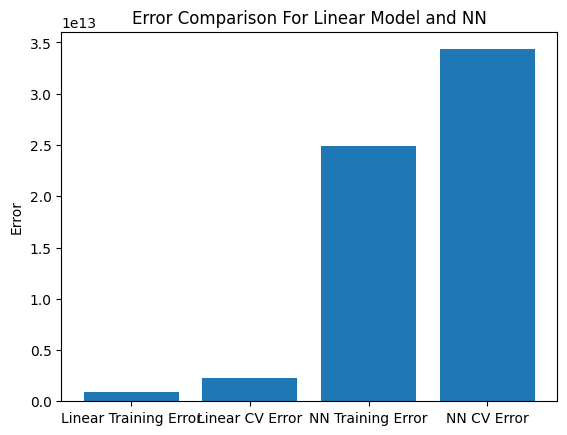

In [24]:
# Compare errors for neural network and linear
y_train_pred_nn = neural_network.predict(X_train)
y_cv_pred_nn = neural_network.predict(X_cv)
error_train_nn = mean_squared_error(y_pred=y_train_pred_nn, y_true=y_train)
error_cv_nn = mean_squared_error(y_pred=y_cv_pred_nn, y_true=y_cv)

print(y_train_pred_nn[:5])

plt.bar(["Linear Training Error", "Linear CV Error", "NN Training Error", "NN CV Error"], [error_on_training_set, error_on_cv_set, error_train_nn, error_cv_nn])
plt.ylabel("Error")
plt.title("Error Comparison For Linear Model and NN")
plt.show()

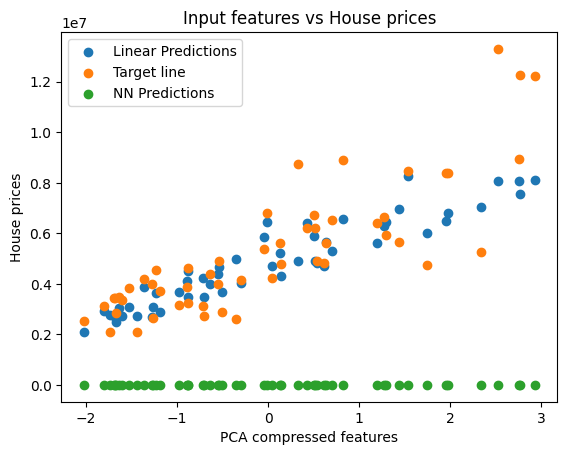

In [16]:
# See predictions for NN, Linear and Actual plotted on scatter plot
plt.scatter(X_cv_pca, y_cv_pred, label="Linear Predictions")
plt.scatter(X_cv_pca, y_cv, label="Target line")
plt.scatter(X_cv_pca, y_cv_pred_nn, label = "NN Predictions")
plt.xlabel("PCA compressed features")
plt.ylabel("House prices")
plt.title("Input features vs House prices")
plt.legend()

plt.show()

# Results

I didn't expect the neural network to be this much worse than the linear regression model, perhaps I just didn't have enought data or there is something wrong with the architecture I decided. Most of the predictions are very low numbers.